# Training vs Re-evaluation Fitness Comparison

Loads the all-time best per-task fitnesses from MLflow for a given experiment,
re-evaluates the corresponding saved genomes over multiple episodes, and
visualises the gap between the two.

In [1]:
# ── Config (edit these to change experiment / evaluation settings) ─────────────
from pathlib import Path

RESULTS_DIR   = Path('../results/multi_task_neat_vs_haneat_v4')   # folder of .npz genomes
EXPERIMENT_NAME = 'multi_task_neat_vs_haneat_v4'                   # MLflow experiment name
DB_PATH       = Path('../mlflow.db').resolve()                     # MLflow SQLite DB
N_EVAL        = 5                                                  # episodes per task for re-eval
BACKEND       = 'mjx'                                              # brax backend
TASKS_CONFIG  = [
    {'env_name': 'hopper',   'obs_size': 11, 'act_size': 3, 'max_step': 1000, 'weight': 1.0},
    {'env_name': 'walker2d', 'obs_size': 17, 'act_size': 6, 'max_step': 1000, 'weight': 1.0},
]
MAX_NODES = 50
MAX_CONNS = 200
# ──────────────────────────────────────────────────────────────────────────────

In [2]:
import sys
sys.path.insert(0, str(Path('../src').resolve()))

import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import jax
import jax.numpy as jnp

from tensorneat.pipeline import Pipeline
from tensorneat.algorithm.neat import NEAT
from tensorneat.genome import DefaultGenome, BiasNode, OriginConn, HANEATMutation
from tensorneat.problem.rl import BraxEnv, MultiTaskBraxEnv, TaskSpec, BRAX_REFERENCE_REWARDS
from tensorneat.common import ACT, AGG, State

mlflow.set_tracking_uri(f'sqlite:///{DB_PATH}')
client = mlflow.tracking.MlflowClient()

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Load Training Best-Fitness from MLflow

In [3]:
exp = client.get_experiment_by_name(EXPERIMENT_NAME)
assert exp is not None, f'Experiment "{EXPERIMENT_NAME}" not found in {DB_PATH}'

all_runs = client.search_runs(exp.experiment_id, max_results=500)
print(f'Runs found in MLflow: {len(all_runs)}')

env_names = [t['env_name'] for t in TASKS_CONFIG]

rows = []
for r in all_runs:
    if r.info.status != 'FINISHED':
        continue
    p = r.data.params
    m = r.data.metrics
    row = {
        'run_id':        r.info.run_id,
        'run_name':      r.info.run_name,
        'algorithm':     p.get('algorithm_type', '?'),
        'pop_size':      int(p.get('pop_size', 0)),
        'seed':          int(p.get('seed', 0)),
        'train_agg':     m.get('best_fitness', float('nan')),
    }
    for env in env_names:
        row[f'train_{env}'] = m.get(f'best_fitness/{env}', float('nan'))
    rows.append(row)

mlflow_df = pd.DataFrame(rows).sort_values(['algorithm', 'seed']).reset_index(drop=True)
mlflow_df

Runs found in MLflow: 4


,run_id,run_name,algorithm,pop_size,seed,train_agg,train_hopper,train_walker2d
0,ebbd2119c89a4b068f566788d1123d0d,ha_neat_normalized_min_pop4096_gen1000_seed42,ha_neat,4096,42,0.472980,1904.817139,2364.899658
1,f50dab8784b640bfaad165417226d227,ha_neat_normalized_min_pop4096_gen1000_seed123,ha_neat,4096,123,0.456611,1369.832153,2329.513916
2,6f17caeda6c843de87f81e4025b6490b,neat_normalized_min_pop4096_gen1000_seed42,neat,4096,42,0.399400,1200.210083,1996.999023


## 2. Build Eval Pipelines

In [4]:
def build_eval_pipeline(is_ha_neat: bool):
    """Construct a minimal Pipeline for genome transformation + forward pass."""
    tasks = []
    for tc in TASKS_CONFIG:
        env = BraxEnv(env_name=tc['env_name'], max_step=tc['max_step'], backend=BACKEND)
        tasks.append(TaskSpec(
            env=env,
            obs_size=tc['obs_size'],
            act_size=tc['act_size'],
            weight=tc['weight'],
            max_reward=BRAX_REFERENCE_REWARDS.get(tc['env_name']),
        ))

    num_inputs  = max(t.obs_size for t in tasks)
    num_outputs = max(t.act_size for t in tasks)

    if is_ha_neat:
        activation_fns = [ACT.tanh, ACT.sigmoid, ACT.relu, ACT.sin, ACT.identity]
        genome = DefaultGenome(
            max_nodes=MAX_NODES, max_conns=MAX_CONNS,
            num_inputs=num_inputs, num_outputs=num_outputs,
            init_hidden_layers=(),
            node_gene=BiasNode(
                activation_options=activation_fns,
                aggregation_options=AGG.sum,
                activation_replace_rate=0.0,
            ),
            conn_gene=OriginConn(),
            mutation=HANEATMutation(activation_mutate_rate=0.1, max_conns=MAX_CONNS),
            output_transform=ACT.tanh,
        )
    else:
        genome = DefaultGenome(
            max_nodes=MAX_NODES, max_conns=MAX_CONNS,
            num_inputs=num_inputs, num_outputs=num_outputs,
            init_hidden_layers=(),
            node_gene=BiasNode(activation_options=ACT.tanh, aggregation_options=AGG.sum),
            output_transform=ACT.tanh,
        )

    algorithm = NEAT(genome=genome, pop_size=2)
    problem   = MultiTaskBraxEnv(tasks=tasks)
    pipeline  = Pipeline(algorithm=algorithm, problem=problem, seed=0, generation_limit=1)
    state     = pipeline.setup()
    return pipeline, state, tasks


print('Building NEAT pipeline...')
pipeline_neat,   state_neat,   eval_tasks = build_eval_pipeline(is_ha_neat=False)
print('Building HA-NEAT pipeline...')
pipeline_haneat, state_haneat, _          = build_eval_pipeline(is_ha_neat=True)
print('Done.')

Building NEAT pipeline...
Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


/Users/svengoerdes/Projects/Thesisv2/tensorneat/.venv/lib/python3.13/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(
W0331 15:37:01.165766 39201963 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


initializing
initializing finished
Building HA-NEAT pipeline...
initializing
initializing finished
Done.


## 3. Re-evaluate Saved Genomes

In [5]:
def evaluate_genome(pipeline, state, tasks, nodes, conns, n_eval=N_EVAL):
    """Return mean and std per-task fitness over n_eval episodes."""
    transformed = pipeline.algorithm.transform(state, (nodes, conns))
    results = {}
    for i, task in enumerate(tasks):
        adapted = pipeline.problem._make_adapted_act_func(
            pipeline.algorithm.forward, task.obs_size, task.act_size
        )
        episode_fitnesses = []
        for ep in range(n_eval):
            key = jax.random.PRNGKey(ep * 100 + i)
            f   = task.env.evaluate(state, key, adapted, transformed)
            episode_fitnesses.append(float(f))
        results[task.env.env_name] = {
            'mean': float(np.mean(episode_fitnesses)),
            'std':  float(np.std(episode_fitnesses)),
        }
    return results


npz_files = sorted(RESULTS_DIR.glob('*.npz'))
assert npz_files, f'No .npz files found in {RESULTS_DIR}'
print(f'Found {len(npz_files)} genome(s). Re-evaluating with N_EVAL={N_EVAL} episodes each...\n')

reeval_rows = []
for path in npz_files:
    fname  = path.name
    is_ha  = fname.startswith('ha_neat')
    pipeline = pipeline_haneat if is_ha else pipeline_neat
    state_   = state_haneat    if is_ha else state_neat

    data  = np.load(path)
    nodes = jnp.array(data['nodes'])
    conns = jnp.array(data['conns'])

    res = evaluate_genome(pipeline, state_, eval_tasks, nodes, conns)
    row = {'npz_file': fname}
    for env_name, stats in res.items():
        row[f'reeval_{env_name}_mean'] = stats['mean']
        row[f'reeval_{env_name}_std']  = stats['std']
    reeval_rows.append(row)
    print(f"  {fname}")
    for env_name, stats in res.items():
        print(f"    {env_name}: {stats['mean']:.1f} ± {stats['std']:.1f}")

reeval_df = pd.DataFrame(reeval_rows)
print('\nRe-evaluation complete.')

Found 3 genome(s). Re-evaluating with N_EVAL=5 episodes each...

  ha_neat_normalized_min_pop4096_gen1000_gen1.0_seed123.npz
    hopper: 751.5 ± 434.6
    walker2d: 1952.9 ± 482.8
  ha_neat_normalized_min_pop4096_gen1000_gen1.0_seed42.npz
    hopper: 1860.4 ± 321.9
    walker2d: 2004.6 ± 162.0
  neat_normalized_min_pop4096_gen1000_gen1.0_seed42.npz
    hopper: 1195.5 ± 3.1
    walker2d: 1986.6 ± 11.3

Re-evaluation complete.


## 4. Match MLflow Runs to .npz Files

In [6]:
def extract_key_from_filename(fname: str) -> tuple:
    """Parse (algorithm, seed) from an npz filename.

    Handles the cosmetic run-name bug where 'gen{gen_limit}_gen{disjoint}'
    appears instead of 'gen{gen_limit}_disjoint{disjoint}'.
    """
    stem = fname.replace('.npz', '')
    parts = stem.split('_')
    algorithm = 'ha_neat' if fname.startswith('ha_neat') else 'neat'
    seed = int(parts[-1].replace('seed', ''))
    return algorithm, seed


reeval_df[['algorithm', 'seed']] = reeval_df['npz_file'].apply(
    lambda f: pd.Series(extract_key_from_filename(f))
)

# Merge on (algorithm, seed) — assumes one run per (algorithm, seed) in the experiment
combined = pd.merge(mlflow_df, reeval_df, on=['algorithm', 'seed'], how='inner')

# Build a clean display label
combined['label'] = combined['algorithm'] + ' seed=' + combined['seed'].astype(str)
combined

,run_id,run_name,algorithm,pop_size,seed,train_agg,train_hopper,train_walker2d,npz_file,reeval_hopper_mean,reeval_hopper_std,reeval_walker2d_mean,reeval_walker2d_std,label
0,ebbd2119c89a4b068f566788d1123d0d,ha_neat_normalized_min_pop4096_gen1000_seed42,ha_neat,4096,42,0.472980,1904.817139,2364.899658,ha_neat_normalized_min_pop4096_gen1000_gen1.0_...,1860.418188,321.915041,2004.637207,161.951411,ha_neat seed=42
1,f50dab8784b640bfaad165417226d227,ha_neat_normalized_min_pop4096_gen1000_seed123,ha_neat,4096,123,0.456611,1369.832153,2329.513916,ha_neat_normalized_min_pop4096_gen1000_gen1.0_...,751.467749,434.577736,1952.915735,482.798806,ha_neat seed=123
2,6f17caeda6c843de87f81e4025b6490b,neat_normalized_min_pop4096_gen1000_seed42,neat,4096,42,0.399400,1200.210083,1996.999023,neat_normalized_min_pop4096_gen1000_gen1.0_see...,1195.483521,3.141329,1986.556104,11.338257,neat seed=42


## 5. Summary Table

In [10]:
display_rows = []
for _, row in combined.iterrows():
    for env in env_names:
        ref = BRAX_REFERENCE_REWARDS.get(env, 1.0)
        train_raw   = row.get(f'train_{env}', float('nan'))
        reeval_mean = row.get(f'reeval_{env}_mean', float('nan'))
        reeval_std  = row.get(f'reeval_{env}_std',  float('nan'))
        gap_pct = (reeval_mean - train_raw) / abs(train_raw) * 100 if not np.isnan(train_raw) else float('nan')
        display_rows.append({
            'Run':                        row['label'],
            'Task':                       env,
            'Train best (raw)':           round(train_raw, 1),
            'Train best (norm)':          round(train_raw / ref, 3),
            f'Re-eval mean (N={N_EVAL})': round(reeval_mean, 1),
            'Re-eval std':                round(reeval_std, 1),
            'Re-eval norm':               round(reeval_mean / ref, 3),
            'Gap %':                      round(gap_pct, 1),
        })

table_df = pd.DataFrame(display_rows)

def color_gap(val):
    if pd.isna(val):
        return ''
    return 'color: green' if val >= 0 else 'color: red'

table_df.style \
    .map(color_gap, subset=['Gap %']) \
    .format({'Gap %': '{:+.1f}%'}) \
    .set_caption(f'Training best-fitness vs {N_EVAL}-episode re-evaluation ({EXPERIMENT_NAME})')

,Run,Task,Train best (raw),Train best (norm),Re-eval mean (N=5),Re-eval std,Re-eval norm,Gap %
0,ha_neat seed=42,hopper,1904.800000,0.635000,1860.400000,321.900000,0.620000,-2.3%
1,ha_neat seed=42,walker2d,2364.900000,0.473000,2004.600000,162.000000,0.401000,-15.2%
2,ha_neat seed=123,hopper,1369.800000,0.457000,751.500000,434.600000,0.250000,-45.1%
3,ha_neat seed=123,walker2d,2329.500000,0.466000,1952.900000,482.800000,0.391000,-16.2%
4,neat seed=42,hopper,1200.200000,0.400000,1195.500000,3.100000,0.398000,-0.4%
5,neat seed=42,walker2d,1997.000000,0.399000,1986.600000,11.300000,0.397000,-0.5%


## 6. Bar Chart: Training vs Re-evaluation

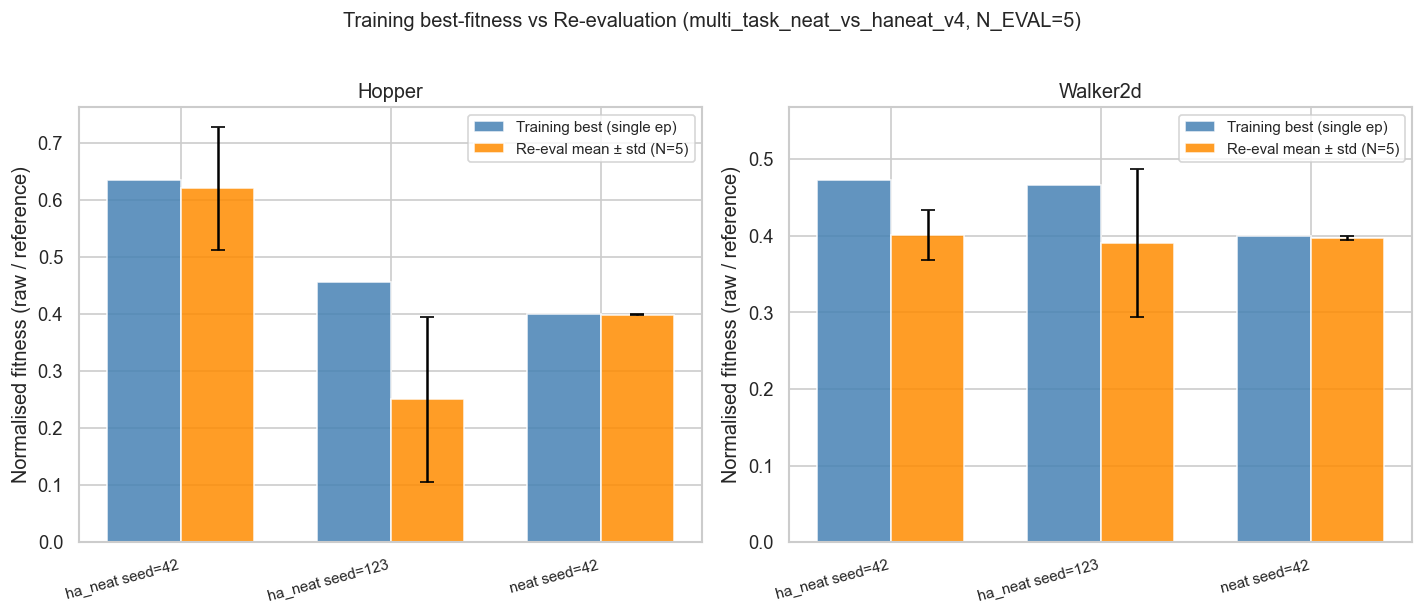

In [9]:
n_runs = len(combined)
n_envs = len(env_names)

fig, axes = plt.subplots(1, n_envs, figsize=(6 * n_envs, 5), sharey=False)
if n_envs == 1:
    axes = [axes]

bar_width = 0.35
x = np.arange(n_runs)
labels = combined['label'].tolist()

for ax, env in zip(axes, env_names):
    ref = BRAX_REFERENCE_REWARDS.get(env, 1.0)

    train_vals  = combined[f'train_{env}'].values / ref
    reeval_vals = combined[f'reeval_{env}_mean'].values / ref
    reeval_errs = combined[f'reeval_{env}_std'].values  / ref

    bars_train  = ax.bar(x - bar_width / 2, train_vals,  bar_width,
                         label='Training best (single ep)', color='steelblue', alpha=0.85)
    bars_reeval = ax.bar(x + bar_width / 2, reeval_vals, bar_width,
                         yerr=reeval_errs, capsize=4,
                         label=f'Re-eval mean ± std (N={N_EVAL})',
                         color='darkorange', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Normalised fitness (raw / reference)')
    ax.set_title(env.capitalize())
    ax.set_ylim(0, max(np.nanmax(train_vals), np.nanmax(reeval_vals)) * 1.2)
    ax.legend(fontsize=9)
    ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, label='Reference reward')

fig.suptitle(
    f'Training best-fitness vs Re-evaluation ({EXPERIMENT_NAME}, N_EVAL={N_EVAL})',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()